In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam
from keras.optimizers import Adam

In [3]:
df = pd.read_csv("dataset_28x28x3.csv", header=None)
Y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values
X = X.astype('float32') / 255.0

encoder = LabelEncoder()
Y = encoder.fit_transform(Y)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Xtrain = Xtrain.reshape((Xtrain.shape[0], 28, 28, 3))
Xtest = Xtest.reshape((Xtest.shape[0], 28, 28, 3))

num_classes = len(np.unique(Y))
Ytrain = to_categorical(Ytrain, num_classes)
Ytest = to_categorical(Ytest, num_classes)

In [6]:
model = Sequential()
model.add(Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,3), padding='same'))
model.add(AveragePooling2D(pool_size=(2,2)))
model.add(Conv2D(16, (5,5), activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax'))

optimizer = Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

In [7]:
history = model.fit(Xtrain, Ytrain, validation_data=(Xtest, Ytest), epochs=15, batch_size=64, verbose=1)

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.3913 - loss: 1.0929 - val_accuracy: 0.4817 - val_loss: 1.0630
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4875 - loss: 1.0200 - val_accuracy: 0.5183 - val_loss: 0.9996
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5567 - loss: 0.9621 - val_accuracy: 0.5567 - val_loss: 0.9906
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5883 - loss: 0.9319 - val_accuracy: 0.6200 - val_loss: 0.9514
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6042 - loss: 0.9105 - val_accuracy: 0.5883 - val_loss: 0.9264
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6250 - loss: 0.8850 - val_accuracy: 0.5967 - val_loss: 0.9251
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6242 - loss: 0.8781 - val_accuracy: 0.6333 - val_loss: 0.9055
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6413 - loss: 0.8677 - val_accuracy: 0.6417 - v

Training Accuracy = [0.39125001430511475, 0.48750001192092896, 0.5566666722297668, 0.5883333086967468, 0.6041666865348816, 0.625, 0.6241666674613953, 0.6412500143051147, 0.653333306312561, 0.6524999737739563, 0.6495833396911621, 0.6499999761581421, 0.6645833253860474, 0.6729166507720947, 0.6754166483879089]
Testing Accuracy = [0.4816666543483734, 0.5183333158493042, 0.5566666722297668, 0.6200000047683716, 0.5883333086967468, 0.596666693687439, 0.6333333253860474, 0.6416666507720947, 0.6266666650772095, 0.6466666460037231, 0.6016666889190674, 0.6200000047683716, 0.6850000023841858, 0.6616666913032532, 0.6366666555404663]
Training Loss = [1.092895746231079, 1.0199556350708008, 0.9621066451072693, 0.9319289326667786, 0.9104920625686646, 0.8850244879722595, 0.8780678510665894, 0.8676695823669434, 0.8503772616386414, 0.8467228412628174, 0.8481324911117554, 0.8363828659057617, 0.818342924118042, 0.7934260964393616, 0.7813876867294312]
Testing Loss = [1.0630240440368652, 0.999599814414978, 0.

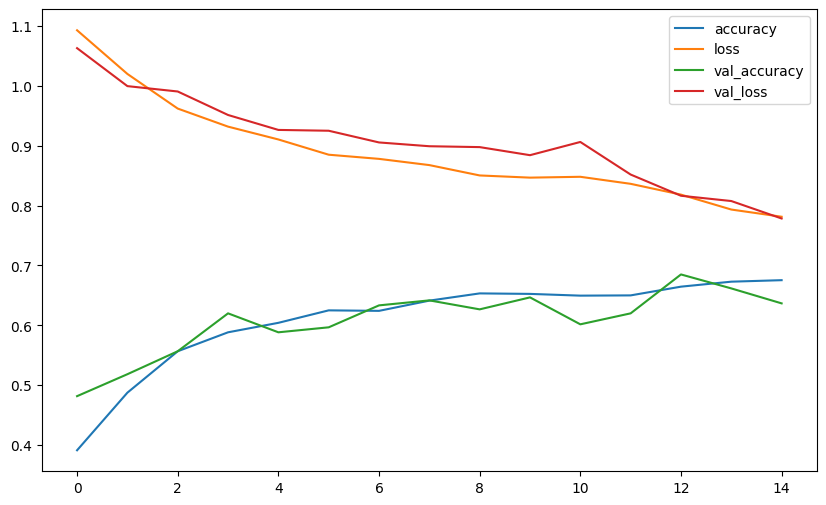

In [8]:
print("Training Accuracy =", history.history['accuracy'])
print("Testing Accuracy =", history.history['val_accuracy'])
print("Training Loss =", history.history['loss'])
print("Testing Loss =", history.history['val_loss'])

pd.DataFrame(history.history).plot(figsize=(10,6))
plt.show()